In [2]:
import numpy as np
import pandas as pd
import os
import warnings
import matplotlib.pyplot as plt
from arch import arch_model
import scipy
import statsmodels.api as sm
import importlib
import MarkovAutoregression_t

In [3]:
file_path = 'E:/RA/Geert/task1.py'
file_path = os.path.abspath(file_path)
dir_path = os.path.dirname(file_path)
os.chdir(dir_path)
excel_file = pd.ExcelFile('Aggregate_CPI_inflation_20230513.xls')
sheet_quarter = excel_file.sheet_names[0]
sheet_month = excel_file.sheet_names[1]
data_quarter = excel_file.parse(sheet_quarter, skiprows=2)
data_month = excel_file.parse(sheet_month, skiprows=2)
data_quarter['Quarter_str'] = data_quarter['Year'].astype(str) + 'Q' + data_quarter['Quarter'].astype(str)
data_quarter.index = pd.PeriodIndex(data_quarter['Quarter_str'], freq='Q').to_timestamp()
data_month.index = pd.to_datetime(data_month['Year'].astype(str) + data_month['Month'].astype(str).str.zfill(2), format='%Y%m')
data_quarter.columns = ['Year', 'Quarter', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock', 'Quarter_str']
data_month.columns = ['Year', 'Month', 'Price index', 'Inflation', 'Forecasted inflation', 'Inflation shock']
sample_data = data_quarter[data_quarter['Year'] > 1969].copy()

In [4]:
sample_data['Inflation_lag_1'] = sample_data['Inflation'].shift(1)
sample_data['Inflation_lag_2'] = sample_data['Inflation'].shift(2)
sample_data['Forecasted_inflation_lag_1'] = sample_data['Forecasted inflation'].shift(1)
sample_data = sample_data.dropna()

## Regime Switching model with constraints

\begin{align}
    y_t = a_{S_t} + x_t' \beta_{S_t} + \phi_{1, S_t}
    (y_{t-1} - a_{S_{t-1}} - x_{t-1}' \beta_{S_{t-1}}) + \dots +
    \phi_{p, S_t} (y_{t-p} - a_{S_{t-p}} - x_{t-p}' \beta_{S_{t-p}}) +
    \varepsilon_t 
\end{align}

Use Kim Smoother and Hamilton filter to calculate marginal probability and joint probability

## Estimation Procedure

In regime-switching models, the likelihood surface is complex and riddled with numerous local maxima. Direct maximization of the likelihood function via standard Maximum Likelihood Estimation (MLE) methods can easily get trapped in one of these local maxima. So I apply following estimation procedure:

1. Random Search: performs a random search for better starting parameters. It draws random parameters around the initial start_params.

2. EM Algorithm: performs a specified number of EM algorithm iterations to further improve the initial parameters.

3. Maximum Likelihood Estimation (MLE): maximizes the likelihood function to find the best-fitting parameters. 

## Expectation-Maximization (EM) algorithm step

EM algorithm is designed to avoid getting stuck in local maxima by incrementally improving the likelihood at each step. EM smoothes the path towards more stable estimates that can be further refined using MLE methods.

### EM for Transition Probability Matrix

1. **Smoothed Joint Probabilities**: Calculate the smoothed probabilities for the transition from one regime to another using Kim Smoother and Hamilton Filter.

$$ P(S_{t-1} = i | Y) = \sum_{j=1}^{k} P(S_t = j, S_{t-1} = i | Y) $$

2. **Transition Probabilities Update**: Use the smoothed probabilities to update the transition probabilities.

$$ p_{ij} = \frac{\sum_{t=2}^{T} P(S_t = j, S_{t-1} = i | Y)}{\sum_{t=2}^{T} P(S_{t-1} = i | Y)} $$

Where $ p_{ij} $ is the probability of transitioning from regime $ i $ to regime $ j$, and $ T $ is the total number of observations.

3. **Normalization**: If the sum of probabilities exceeds 1 due to rounding errors, normalize the probabilities:

$$ p_{ij} \leftarrow \frac{p_{ij}}{\sum_{j=1}^{k} p_{ij}} $$

This ensures that the transition probabilities for each starting regime $ i $ sum to 1.

4. **Numerical Stability**: To avoid numerical instability, such as division by zero, a small constant $ \epsilon  $  is added:

$$ p_{ij} \leftarrow \frac{p_{ij}}{1 + \sum_{j=1}^{k} p_{ij} - 1 + \epsilon} $$


### EM for Exogenous Variable


### Non-Switching Coefficients

1. **Estimate Non-Switching Coefficients**:
   If there are coefficients that do not switch between regimes:

   $$ \text{coeffs}_{\text{non-switching}} = (X_{\text{non-switching}}'X_{\text{non-switching}})^{-1} X_{\text{non-switching}}'Y $$

   Here, $X_{\text{non-switching}} $is the design matrix of exogenous variables that do not switch, and $ Y $ is the vector of endogenous variables. These coefficients are assumed to be the same across all regimes.

### Switching Coefficients

2. **Preparation for Switching Coefficients**:
   For coefficients that do switch with regimes, the exogenous data is weighted by the square root of the smoothed marginal probabilities of being in each regime.

   $$ \tilde{Y} = \sqrt{P(S_t | Y)} \cdot Y $$
   $$ \tilde{X}_{\text{switching}} = \sqrt{P(S_t | Y)} \cdot X_{\text{switching}} $$

   where $ P(S_t | Y) $ are the smoothed marginal probabilities of each regime at time $ t $.

3. **Estimate Switching Coefficients**:
   Each regime's switching coefficients are estimated by applying the weighted least squares:

   $$ \text{coeffs}_{\text{switching}, i} = (\tilde{X}_{\text{switching}, i}' \tilde{X}_{\text{switching}, i})^{-1} \tilde{X}_{\text{switching}, i}' \tilde{Y}_i $$

   Here, the tilde denotes the weighted matrices and vectors, and $ i $ indexes the regime.


### EM for Autoregression

First, residuals are calculated for each regime. For each regime `i`:

1. Subtract the influence of exogenous variables from the original endogenous series, if applicable.
2. Create a lag matrix of the residuals, which serves as the regime-specific exogenous variables in the autoregressive process.
3. Use these lagged residuals to estimate the autoregressive coefficients by minimizing the weighted least squares problem.
4. If `switching_variance` is `True`, calculate the variance for each regime separately. Otherwise, compute a single variance across all regimes.

### Mathematical Details

- The residuals for each regime `i` are defined as:
  $$ \text{resid}_i = \text{orig_endog} - \text{orig_exog} \cdot \text{betas}[i] $$

- The autoregressive coefficients for each regime are estimated using the lagged values of the residuals:
  $$ \text{coeffs}[i] = (\text{tmp_exog}^T \cdot \text{tmp_exog})^{-1} \cdot \text{tmp_exog}^T \cdot \text{tmp_endog} $$

- The variance for each regime:
  $$ \text{variance}[i] = \frac{\sum (\text{tmp_resid}^2 \cdot \text{result.smoothed_marginal_probabilities}[i])}{\sum \text{result.smoothed_marginal_probabilities}[i]} $$

- If `switching_variance` is `False`, the combined variance across all regimes is calculated as the sum of squared residuals divided by the number of observations.


### EM for Variance

### Switching Variance

For each regime $i$:

1. Compute the residuals:
   - If exogenous variables are present, residuals are calculated as $ \text{resid}_i = endog - exog \cdot \text{betas}[i] $.
   - Otherwise, residuals are simply the endogenous variables.

2. Estimate the variance for each regime as:
   - $ \text{variance}[i] = \frac{\sum (\text{resid}_i^2 \cdot \text{smoothed_marginal_probabilities}[i])}{\sum \text{smoothed_marginal_probabilities}[i]} $

### Non-Switching Variance

If variances do not switch between regimes:

1. Optionally, weight the endogenous variables by the square root of the smoothed marginal probabilities.

2. Compute the weighted residuals for each regime:
   - If exogenous variables are present, adjust them with the weights and calculate the residuals.

3. The overall variance is then the weighted sum of squared residuals divided by the number of observations:
   - $ \text{variance} = \frac{\sum_{i} \text{resid}_i^2}{nobs} $


### EM for Nu

The process involves the following steps for each regime `i`:

1. Calculate residuals, which are the differences between the observed data and the model's predictions.
2. Compute the variance of these residuals.
3. Scale the residuals by their standard deviation.
4. Calculate the sample kurtosis of the scaled residuals.
5. Use the sample kurtosis to estimate `nu` by matching it with the theoretical kurtosis of the t-distribution.

If `switching_nu` is `True`, this process is done for each regime. Otherwise, a fixed `nu` is used, often set to 15 as a starting value in statistical software for robustness.

### Mathematical Details

- The residuals for each regime `i`:
  $$ \text{resid} = \text{endog} - \text{exog} \cdot \text{betas}[i] $$

- The variance for the residuals:
  $$ \text{variance} = \frac{\sum(\text{resid}^2 \cdot \text{smoothed_marginal_probabilities}[i])}{\sum \text{smoothed_marginal_probabilities}[i]} $$

- The sample kurtosis for scaled residuals is calculated, and the degrees of freedom `nu` is estimated by equating it with the theoretical kurtosis of the t-distribution:
  $$ \text{sample_kurt} = \text{kurtosis}(\text{scaled_resid}, \text{fisher=False}, \text{bias=False}) $$
  $$ \text{theoretical_kurt} = \frac{3 \cdot (\nu[i] - 2)}{(\nu[i] - 4)} $$
  $$ \nu[i] = \text{solve_for_nu}(\text{sample_kurt}, \text{theoretical_kurt}) $$


# Report 

In [16]:
importlib.reload(MarkovAutoregression_t)

<module 'MarkovAutoregression_t' from 'C:\\Users\\Administrator\\MarkovAutoregression_t.py'>

In [17]:
res = MarkovAutoregression_t.MarkovAutoregression_t(
    endog=sample_data['Inflation'], 
    exog=sample_data['Forecasted inflation'],
    k_regimes=2, 
    order=1, 
    trend="n",
    switching_trend=False,
    switching_exog = False,
    switching_variance=True, 
    switching_nu=True,
    ).fit()
res.summary()

C:\Users\Administrator\MarkovAutoregression_t.py:103: ComplexWarning: Casting complex values to real discards the imaginary part
  # lls = -0.5 * (log(2 * pi) + log(sigma2) + resids ** 2.0 / sigma2)
C:\Users\Administrator\MarkovAutoregression_t.py:104: ComplexWarning: Casting complex values to real discards the imaginary part
  


<class 'statsmodels.iolib.summary.Summary'>
"""
                          Markov Switching Model Results                          
==================================================================================
Dep. Variable:                  Inflation   No. Observations:                  209
Model:             MarkovAutoregression_t   Log Likelihood                -172.212
Date:                    Wed, 08 Nov 2023   AIC                            362.424
Time:                            10:36:31   BIC                            392.505
Sample:                        07-01-1970   HQIC                           374.586
                             - 10-01-2022                                         
Covariance Type:                   approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0932        nan        nan        nan         nan         nan
ar.L1          0.0029      0.053      0.055      0.956      -0.102       0.107
nu             9.5129        nan        nan        nan         nan         nan
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.6878        nan        nan        nan         nan         nan
ar.L1          0.4168      0.042      9.969      0.000       0.335       0.499
nu            15.7473        nan        nan        nan         nan         nan
                                Non-switching parameters                                
========================================================================================
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Forecasted inflation     1.0352      0.016     65.780      0.000       1.004       1.066
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.8886      0.013     68.946      0.000       0.863       0.914
p[1->0]        0.1413      0.017      8.398      0.000       0.108       0.174
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

In [15]:
RS_results(endog=sample_data['Inflation'], 
    exog=sample_data['Forecasted inflation'],
    order=2)

NameError: name 'RS_results' is not defined

In [121]:
res = sm.tsa.MarkovAutoregression(
    endog=sample_data['Inflation'], 
    exog=sample_data['Forecasted inflation'],
    k_regimes=2, 
    order=2, 
    trend="n",
    switching_exog = True,
    switching_variance=True).fit()
res.params

p[0->0]                    0.720123
p[1->0]                    0.119200
Forecasted inflation[0]    0.921303
Forecasted inflation[1]    1.309935
sigma2[0]                  0.706690
sigma2[1]                  0.153024
ar.L1[0]                  -0.015590
ar.L1[1]                   0.323537
ar.L2[0]                  -0.285538
ar.L2[1]                   0.369153
dtype: float64

In [109]:
p = res.params

In [129]:
type(list(p))
list(p)+[5,10]

[0.6877832105840749,
 0.1383732494149721,
 -0.06005282038437099,
 -0.743579388088271,
 -0.033539558554653154,
 1.0769607401589276,
 0.6610908675463083,
 0.14279954061318018,
 -0.03014526254665858,
 0.36128209141385265,
 -0.28117299992834455,
 0.43175960832227495,
 5,
 10]

In [124]:
res.param_names

['p[0->0]',
 'p[1->0]',
 'Forecasted inflation[0]',
 'Forecasted inflation[1]',
 'sigma2[0]',
 'sigma2[1]',
 'ar.L1[0]',
 'ar.L1[1]',
 'ar.L2[0]',
 'ar.L2[1]',
 'nu[0]',
 'nu[1]']

In [130]:
res.start_params=list(p)+[5,10]

AttributeError: can't set attribute

In [122]:
res = MarkovAutoregression_t.MarkovAutoregression_t(
    endog=sample_data['Inflation'], 
    exog=sample_data['Forecasted inflation'],
    k_regimes=2, 
    order=2, 
    trend="n",
    switching_exog = True,
    switching_variance=True,
    switching_nu=True,
    )

In [136]:
res.fit(start_params=list(p)+[6,4])

LinAlgError: SVD did not converge

## Empirical Results

Model Specification:
1. Regime Heteroskedasticity (In every regime, variance is the same)
2. Constant Transition Probabilities
3. Estimation method: Maximum Likelihood Function

$
\pi (t) =  fc(t-1) + \epsilon (t)
$

In [8]:
res = sm.tsa.MarkovRegression( sample_data['Inflation shock'], k_regimes=2, trend="n", switching_variance=True).fit()
res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                        Markov Switching Model Results                        
==============================================================================
Dep. Variable:        Inflation shock   No. Observations:                  208
Model:               MarkovRegression   Log Likelihood                -176.849
Date:                Sat, 04 Nov 2023   AIC                            361.697
Time:                        13:21:20   BIC                            375.048
Sample:                    01-01-1971   HQIC                           367.096
                         - 10-01-2022                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.1349      0.024      5.649      0.000       0.088       0.182
                             Regime 1 parameters                              
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         1.3373      0.310      4.316      0.000       0.730       1.945
                         Regime transition parameters                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
p[0->0]        0.9453      0.028     34.064      0.000       0.891       1.000
p[1->0]        0.1461      0.065      2.251      0.024       0.019       0.273
==============================================================================

Warnings:
[1] Covariance matrix calculated using numerical (complex-step) differentiation.
"""

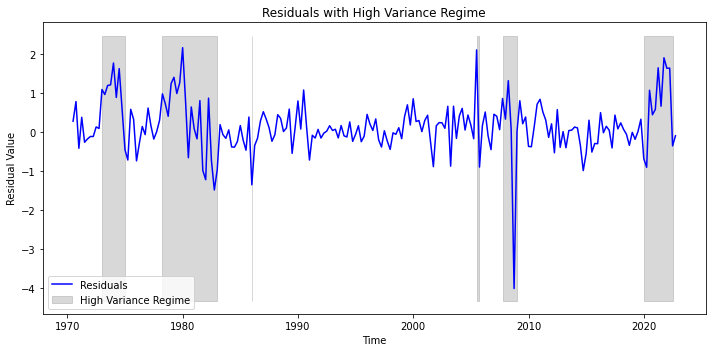

In [49]:
endog = sample_data['Inflation shock']
fig, ax = plt.subplots(figsize=(10,5))

# Plot residuals 
residuals = endog 

# Extract variance for each regime
variances = [res.params[f'sigma2[{i}]'] for i in range(2)]
high_variance_regime_idx = np.argmax(variances)

high_variance_regime = (res.smoothed_marginal_probabilities.iloc[:, high_variance_regime_idx] > 0.5).astype(int)

# Align the datasets
aligned_residuals, aligned_regime = residuals.align(high_variance_regime, join='inner')

ax.plot(aligned_residuals, label="Residuals", color='blue')

# Shade regions where variance is larger
ax.fill_between(aligned_residuals.index, ax.get_ylim()[0], ax.get_ylim()[1], where=aligned_regime==1, color='grey', alpha=0.3, label='High Variance Regime')

ax.set(title="Residuals with High Variance Regime", xlabel="Time", ylabel="Residual Value")
ax.legend()

plt.tight_layout()
plt.show()

$
\pi (t) = c +\rho \pi (t-1)   + \phi fc(t-1) + \epsilon (t)
$

                         Markov Switching Model Results                         
Dep. Variable:                Inflation   No. Observations:                  209
Model:             MarkovAutoregression   Log Likelihood                -169.185
Date:                  Mon, 21 Aug 2023   AIC                            358.369
Time:                          20:38:15   BIC                            391.792
Sample:                      07-01-1970   HQIC                           371.882
                           - 10-01-2022                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2024      0.089      2.270      0.023       0.028       0.377
x1             0.7885      0.116    

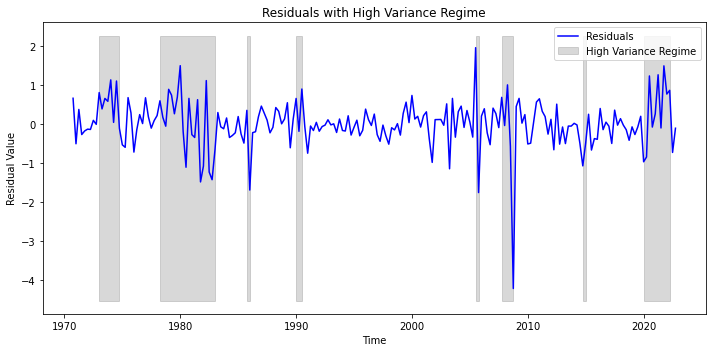

In [40]:
regime_switching_ar(endog = sample_data['Inflation'], exog=sample_data['Forecasted inflation'],lag=1)

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi fc(t-1) + \epsilon (t)
$

                         Markov Switching Model Results                         
Dep. Variable:                Inflation   No. Observations:                  208
Model:             MarkovAutoregression   Log Likelihood                -175.274
Date:                  Mon, 21 Aug 2023   AIC                            374.548
Time:                          20:43:32   BIC                            414.598
Sample:                      07-01-1970   HQIC                           390.742
                           - 10-01-2022                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0235      0.177      0.133      0.894      -0.324       0.371
x1             0.9006      0.145    

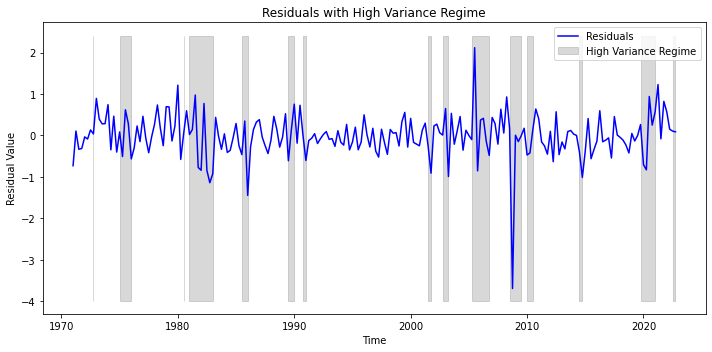

In [46]:
regime_switching_ar(endog = sample_data['Inflation'], exog=sample_data['Forecasted inflation'],lag=2)

$
\pi (t) = c +\rho_1 \pi (t-1)  +\rho_2 \pi (t-2)  + \phi_1 fc(t-1) + \phi_2 fc(t-2) + \epsilon (t)
$

                         Markov Switching Model Results                         
Dep. Variable:                Inflation   No. Observations:                  208
Model:             MarkovAutoregression   Log Likelihood                -172.190
Date:                  Mon, 21 Aug 2023   AIC                            372.380
Time:                          20:43:25   BIC                            419.105
Sample:                      07-01-1970   HQIC                           391.273
                           - 10-01-2022                                         
Covariance Type:                 approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0193      0.200     -0.097      0.923      -0.411       0.372
x1             0.8504      0.861    

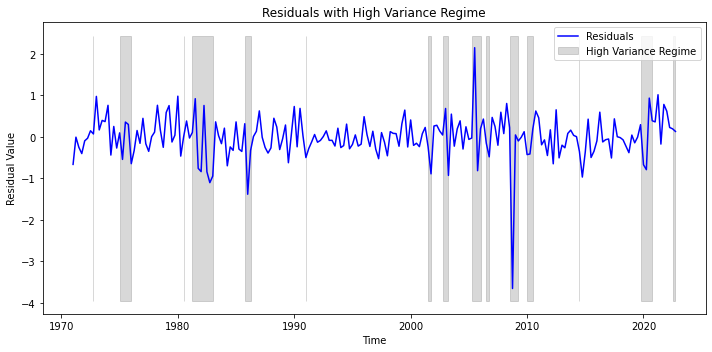

In [45]:
regime_switching_ar(endog = sample_data['Inflation'], exog=sample_data[['Forecasted inflation','Forecasted_inflation_lag_1']],lag=2)

In [7]:
def regime_switching_ar(endog, exog,num_of_regime=2, lag=1, plot=True):
    # Fit the model
    model = sm.tsa.MarkovAutoregression(
        endog, k_regimes=num_of_regime, order=lag, 
        exog=exog, switching_ar=True,switching_exog=True, switching_variance=True,)
    res = model.fit()

    # Print the summary
    print(res.summary())

    # Plot the series with regimes if requested
    if plot:
        fig, ax = plt.subplots(figsize=(10,5))

        # Plot residuals
        residuals = endog - res.fittedvalues
        residuals = residuals.dropna()  # Drop NA values caused by lags
        
        # Extract variance for each regime
        variances = [res.params[f'sigma2[{i}]'] for i in range(num_of_regime)]
        high_variance_regime_idx = np.argmax(variances)

        high_variance_regime = (res.smoothed_marginal_probabilities.iloc[:, high_variance_regime_idx] > 0.5).astype(int)

        # Align the datasets
        aligned_residuals, aligned_regime = residuals.align(high_variance_regime, join='inner')

        ax.plot(aligned_residuals, label="Residuals", color='blue')
        
        # Shade regions where variance is larger
        ax.fill_between(aligned_residuals.index, ax.get_ylim()[0], ax.get_ylim()[1], where=aligned_regime==1, color='grey', alpha=0.3, label='High Variance Regime')

        ax.set(title="Residuals with High Variance Regime", xlabel="Time", ylabel="Residual Value")
        ax.legend()

        plt.tight_layout()
        plt.show()

    return res